Obs: Converter em um arquivo .py para rodar.

# Importações

In [2]:
import abc

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import warnings

from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from pyswarms.single import GlobalBestPSO
from sklearn.model_selection import TimeSeriesSplit, train_test_split

from anneal import Annealer

MODELOS = ["MLP", "RF", "XGBoost"]
SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
OTIMIZADORES = ["PSO", "SA"]
N_CLASSES = [2, 3, 4, 5, 6, 7, 8, 9, 10]
N_ITER = 15
N_SOLUCOES = 15
K_FOLDS = 5

warnings.filterwarnings('ignore')


def reset_seed(rnd_seed):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


reset_seed(100)


# Configuração dos Otimizadores
## Otimizador Base

In [ ]:
class Otimizador:

    @abc.abstractmethod
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        reset_seed(seed)
        self.nome_modelo = None
        self.dataset = dataset
        self.features = features
        self.seed = seed
        self.n_solucoes = n_solucoes
        self.n_iteracoes = n_iteracoes
        self.solucoes = []
        self.iteracoes = []
        self.n_classes = len(dataset["CLASSE"].unique())

    @abc.abstractmethod
    def run(self):
        pass

    @abc.abstractmethod
    def run_objective_function(self, parametros):
        pass

    def objective_function(self, modelo):
        cvs_todos = []

        for campus, dados in self.dataset.groupby("CAMPUS"):
            previsoes = []
            valores_reais = []

            for i_treino, i_teste in TimeSeriesSplit(n_splits=K_FOLDS, test_size=1).split(dados):
                x = dados[self.features]
                y = dados["CLASSE"]

                x_treino = x.iloc[i_treino]
                y_treino = y.iloc[i_treino]
                x_teste = x.iloc[i_teste]
                y_teste = y.iloc[i_teste]

                modelo.fit(x_treino, y_treino)

                y_previsto = modelo.predict(x_teste)[0]
                previsoes.append(y_previsto)
                valores_reais.append(y_teste)

            cvs_todos.append(accuracy_score(valores_reais, previsoes))

        return np.array(cvs_todos).mean() * - 1

    def iteracoes_dataframe(self):
        df = pd.DataFrame()
        for i in range(len(self.iteracoes)):
            part = self.iteracoes[i]
            df = pd.concat([df, pd.DataFrame.from_dict(part.to_dict(), orient='index').T], ignore_index=True)
        return df

    def salvar_csv(self):
        pd_df = self.iteracoes_dataframe()
        os.makedirs(f"resultados/otimização - classificação/{self.n_classes} classes", exist_ok=True)
        pd_df.to_csv(f"resultados/otimização - classificação/{self.n_classes} classes/{self.n_classes} CLASSES {self.nome_modelo} SEED {self.seed}.csv",
                     sep=";",
                     decimal=".",
                     index=True)


### MLP

In [ ]:
class SolucaoMLP:
    def __init_(self):
        self.fitness = None
        self.hidden_layer_sizes = 0
        self.alpha = 0
        self.activation = None

    def to_dict(self):
        return {
            "Hidden Layers": self.hidden_layer_sizes,
            "Alpha": self.alpha,
            "Activation": self.activation,
            "Fitness": self.fitness,
        }


### Random Forest

In [ ]:
class SolucaoRF:
    def __init_(self):
        self.fitness = None
        self.estimators = 0
        self.max_depth = 0
        self.min_samples_split = 0
        self.min_samples_leaf = 0

    def to_dict(self):
        return {
            "N_estimators": self.estimators,
            "Max_depth": self.max_depth,
            "Min_samples_split": self.min_samples_split,
            "Min_samples_leaf": self.min_samples_leaf,
            "Fitness": self.fitness,
        }

### XGBoost

In [ ]:
class SolucaoXGB:
    def __init_(self):
        self.fitness = None
        self.estimators = 0
        self.max_depth = 0
        self.booster = None
        self.reg_lambda = 0
        self.reg_alpha = 0

    def to_dict(self):
        return {
            "N_estimators": self.estimators,
            "Max_depth": self.max_depth,
            "Booster": self.booster,
            "Lambda": self.reg_lambda,
            "Alpha": self.reg_alpha,
            "Fitness": self.fitness,
        }


## Simulated Annealing (SA)

In [ ]:
class SimulatedAnneal(Annealer):
    def __init__(self, params, objective_function, max_iter):
        self.params = params
        self.objective_function = objective_function
        super().__init__(self.random_initial_state())
        self.steps = max_iter
        self.Tmin = 0.0001
        self.Tmax = 1
        self.updates = 0
        self.anneal()

    def random_initial_state(self):
        initial_state = {}
        for key in self.params.keys():
            initial_state[key] = random.choice(self.params[key])
        return initial_state

    def move(self):
        atual = self.state
        for key in self.params.keys():
            valor = atual[key]
            opcoes = len(self.params[key])
            if opcoes <= 2:
                self.state[key] = random.choice(self.params[key])
            else:
                intervalo = int(np.round(self.T * opcoes))
                diferencas = np.abs(np.array(self.params[key]) - valor)
                index = np.argmin(diferencas)
                inicio = max(0, index - intervalo)
                fim = min(opcoes - 1, index + intervalo)
                if inicio == fim:
                    self.state[key] = self.params[key][inicio]
                else:
                    self.state[key] = self.params[key][random.choice(range(inicio, fim))]

    def energy(self):
        return self.objective_function(self.state)

### MLP

In [ ]:
class SAMLP(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-MLP"
        self.ACTIVATIONS = ["identity", "logistic", "tanh", "relu"]
        self.run()

    def run(self):
        parametros = {
            "hidden_layer_sizes": range(10, 400),
            "alpha": np.arange(0, 1, 0.01),
            "activation": range(0, 4),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoMLP()
        solucao.hidden_layer_sizes = int(parametros["hidden_layer_sizes"])
        solucao.alpha = round(parametros["alpha"], 4)
        solucao.activation = self.ACTIVATIONS[int(parametros["activation"])]

        search = list(filter(lambda par:
                             par.hidden_layer_sizes == solucao.hidden_layer_sizes and
                             par.alpha == solucao.alpha and
                             par.activation == solucao.activation, self.solucoes))

        if search:
            solucao = search[0]

        else:
            modelo = MLPClassifier(hidden_layer_sizes=(solucao.hidden_layer_sizes,),
                                   activation=solucao.activation,
                                   alpha=solucao.alpha,
                                   random_state=self.seed)

            solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

### Random Forest


In [ ]:
class SARF(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-RF"
        self.run()

    def run(self):
        parametros = {
            "estimators": range(10, 400),
            "max_depth": range(10, 400),
            "min_samples_split": range(2, 50),
            "min_samples_leaf": range(2, 50),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoRF()
        solucao.estimators = int(parametros["estimators"])
        solucao.max_depth = int(parametros["max_depth"])
        solucao.min_samples_split = int(parametros["min_samples_split"])
        solucao.min_samples_leaf = int(parametros["min_samples_leaf"])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.min_samples_split == solucao.min_samples_split and
                             par.min_samples_leaf == solucao.min_samples_leaf, self.solucoes))

        if search:
            solucao = search[0]

        else:
            modelo = RandomForestClassifier(random_state=self.seed,
                                            n_estimators=solucao.estimators,
                                            max_depth=solucao.max_depth,
                                            min_samples_split=solucao.min_samples_split,
                                            min_samples_leaf=solucao.min_samples_leaf)

            solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness


### XGBoost

In [ ]:
class SAXGB(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-XGBoost"
        self.BOOSTERS = ["gbtree", "gblinear", "dart"]
        self.run()

    def run(self):
        parametros = {
            "estimators": range(10, 400),
            "max_depth": range(10, 400),
            "booster": range(0, 2),
            "reg_lambda": np.arange(0, 1, 0.005),
            "reg_alpha": np.arange(0, 1, 0.005),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoXGB()
        solucao.estimators = int(parametros["estimators"])
        solucao.max_depth = int(parametros["max_depth"])
        solucao.booster = self.BOOSTERS[int(parametros["booster"])]
        solucao.reg_lambda = float(parametros["reg_lambda"])
        solucao.reg_alpha = float(parametros["reg_alpha"])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.booster == solucao.booster and
                             par.reg_lambda == solucao.reg_lambda and
                             par.reg_alpha == solucao.reg_alpha, self.solucoes))

        if search:
            solucao = search[0]

        else:
            updater = "coord_descent" if solucao.booster == "gblinear" else None
            modelo = XGBClassifier(random_state=self.seed,
                                   n_estimators=solucao.estimators,
                                   max_depth=solucao.max_depth,
                                   booster=solucao.booster,
                                   reg_lambda=solucao.reg_lambda,
                                   reg_alpha=solucao.reg_alpha,
                                   updater=updater)

            solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

## Particle Swarm Optimization (PSO)

### MLP

In [ ]:
class PSOMLP(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-MLP"
        self.ACTIVATIONS = ["identity", "logistic", "tanh", "relu"]
        self.run()

    def run(self):
        lower_bound = [10, 0, 0]
        uppper_bound = [400, 1.0, 4]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=3,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoMLP()
        solucao.hidden_layer_sizes = int(particle_arr[0])
        solucao.alpha = particle_arr[1]
        solucao.activation = self.ACTIVATIONS[int(particle_arr[2])]

        search = list(filter(lambda par:
                             par.hidden_layer_sizes == solucao.hidden_layer_sizes and
                             par.alpha == solucao.alpha and
                             par.activation == solucao.activation, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        modelo = MLPClassifier(hidden_layer_sizes=(solucao.hidden_layer_sizes,),
                               activation=solucao.activation,
                               alpha=solucao.alpha,
                               random_state=self.seed)

        solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        return solucao.fitness

### Random Forest


In [ ]:
class PSORF(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-RF"
        self.run()

    def run(self):
        lower_bound = [10, 10, 2, 2]
        uppper_bound = [400, 400, 50, 50]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=4,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoRF()
        solucao.estimators = int(particle_arr[0])
        solucao.max_depth = int(particle_arr[1])
        solucao.min_samples_split = int(particle_arr[2])
        solucao.min_samples_leaf = int(particle_arr[3])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.min_samples_split == solucao.min_samples_split and
                             par.min_samples_leaf == solucao.min_samples_leaf, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        modelo = RandomForestClassifier(random_state=self.seed,
                                        n_estimators=solucao.estimators,
                                        max_depth=solucao.max_depth,
                                        min_samples_split=solucao.min_samples_split,
                                        min_samples_leaf=solucao.min_samples_leaf)

        solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        return solucao.fitness


### XGBoost

In [ ]:
class PSOXGB(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-XGBoost"
        self.BOOSTERS = ["gbtree", "gblinear", "dart"]
        self.run()

    def run(self):
        lower_bound = [10, 10, 0, 0, 0]
        uppper_bound = [400, 400, 2, 1, 1]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=5,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoXGB()
        solucao.estimators = int(particle_arr[0])
        solucao.max_depth = int(particle_arr[1])
        solucao.booster = self.BOOSTERS[int(particle_arr[2])]
        solucao.reg_lambda = round(particle_arr[3], 4)
        solucao.reg_alpha = round(particle_arr[4], 4)

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.booster == solucao.booster and
                             par.reg_lambda == solucao.reg_lambda and
                             par.reg_alpha == solucao.reg_alpha, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        updater = "coord_descent" if solucao.booster == "gblinear" else None
        modelo = XGBClassifier(random_state=self.seed,
                               n_estimators=solucao.estimators,
                               max_depth=solucao.max_depth,
                               booster=solucao.booster,
                               reg_lambda=solucao.reg_lambda,
                               reg_alpha=solucao.reg_alpha,
                               updater=updater)

        solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        return solucao.fitness


# Carregar Datasets

In [2]:
df_features = pd.read_csv("resultados/features/fitness_features_regressao.csv", sep=";", decimal=".")

df_features = df_features.sort_values("RRMSE").head(1).reset_index(drop=True)
df_features = pd.DataFrame(
    columns=str(df_features.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "))

df_features = df_features.columns
df_features


Index(['TEMP_MÉD_MIN_MENS', 'TEMP_MÉD_MÉD_MENS', 'PRECIPITAÇÃO_MÉD_MENS',
       'TEMP_MIN_MAX_MENS', 'TEMP_MAX_MIN_MENS', 'PRECIPITAÇÃO_MIN_MENS',
       'TEMP_MAX_MAX_MENS', 'DIA_DA_SEMANA_dom', 'DIA_DA_SEMANA_seg',
       'DIA_DA_SEMANA_sáb', 'DIA_DA_SEMANA_ter', 'MÊS_abr', 'MÊS_ago',
       'MÊS_fev', 'MÊS_jun', 'MÊS_mai', 'MÊS_nov', 'ANO_2021', 'ANO_2022',
       'ANO_2023', 'ANO_2015', 'ANO_2016', 'ANO_2017', 'ANO_2018', 'ANO_2019',
       'CAMPUS_ASTORGA', 'CAMPUS_CAMPO LARGO', 'CAMPUS_CAPANEMA',
       'CAMPUS_CASCAVEL', 'CAMPUS_CORONEL VIVIDA', 'CAMPUS_CURITIBA',
       'CAMPUS_GOIOERÊ', 'CAMPUS_IVAIPORÃ', 'CAMPUS_JAGUARIAÍVA',
       'CAMPUS_LONDRINA - CENTRO', 'CAMPUS_PALMAS', 'CAMPUS_PARANAGUÁ',
       'CAMPUS_PINHAIS', 'CAMPUS_TELÊMACO BORBA', 'CAMPUS_UMUARAMA',
       'CURSOS_TEC_SUBSEQUENTE', 'CURSOS_GRAD_MATUTINO',
       'CURSOS_GRAD_VESPERTINO', 'CURSOS_GRAD_NOTURNO', 'CURSOS_POS', 'FÉRIAS',
       'COVID', 'LAG_01', 'LAG_02', 'LAG_03', 'LAG_05', 'LAG_07', 'LAG_09'],



# Execução da Otimização

In [ ]:
for n_classe in N_CLASSES:
    df_consumo = pd.read_csv(f"./dados/classes/{n_classe}_classes_normalizadas_lagadas.csv", sep=';', decimal='.')
    df_consumo = df_consumo.sort_values("CAMPUS").sort_values("DATA")

    dataframes = []
    for campus, dados in df_consumo.groupby("CAMPUS"):
        if len(dados) < 100:
            continue
        treino, teste = train_test_split(dados, test_size=12, shuffle=False)
        dataframes.append(treino)

    df_consumo = pd.concat(dataframes, ignore_index=True)
    df_consumo = df_consumo.sort_values("CAMPUS").sort_values("DATA")

    for seed in SEEDS:
        print(f"Classes: {n_classe} SEED: {seed}")
        PSOMLP(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        PSORF(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        PSOXGB(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        SAMLP(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        SARF(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        SAXGB(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)

# Optimization Results
## Fitness Evolution

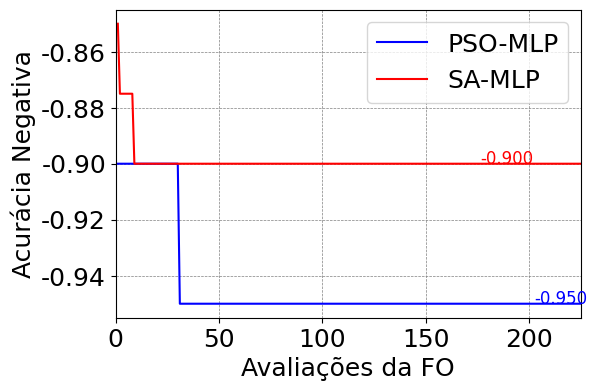

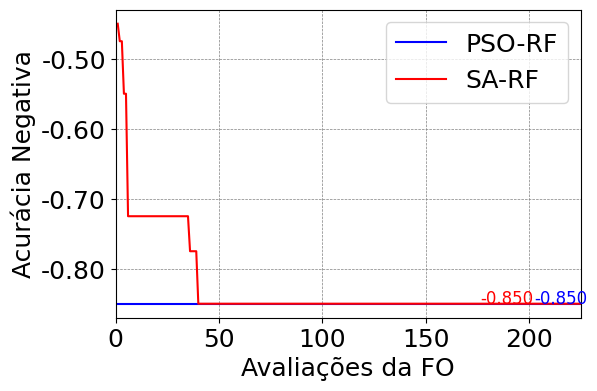

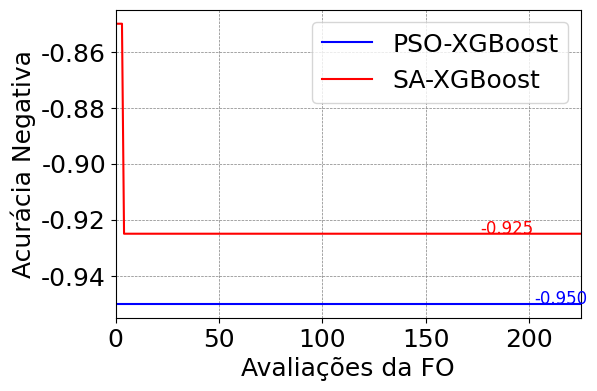

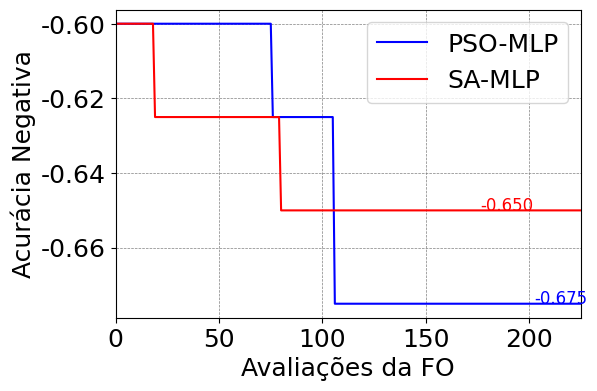

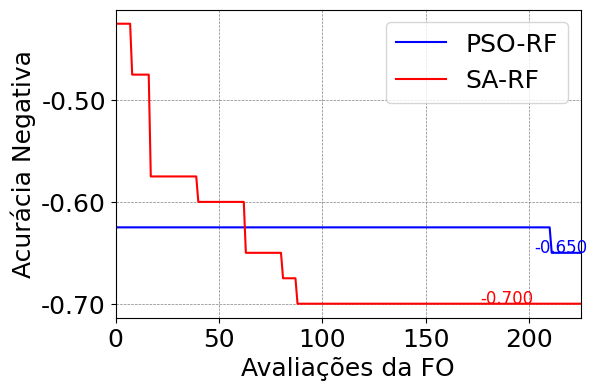

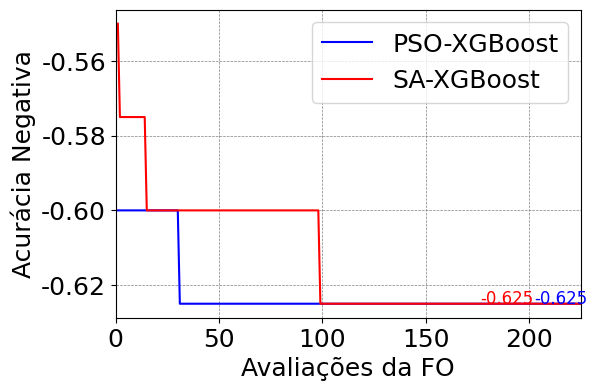

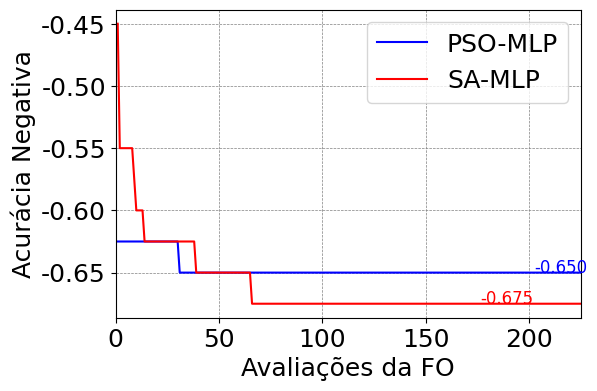

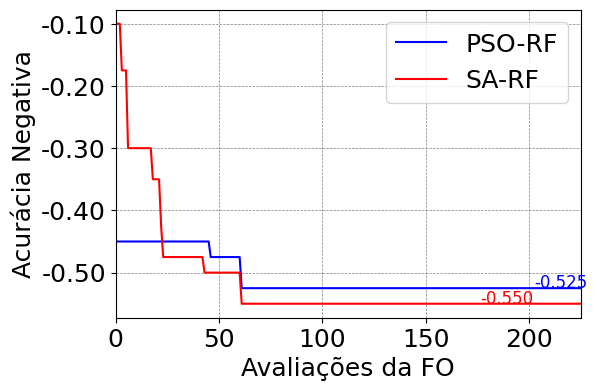

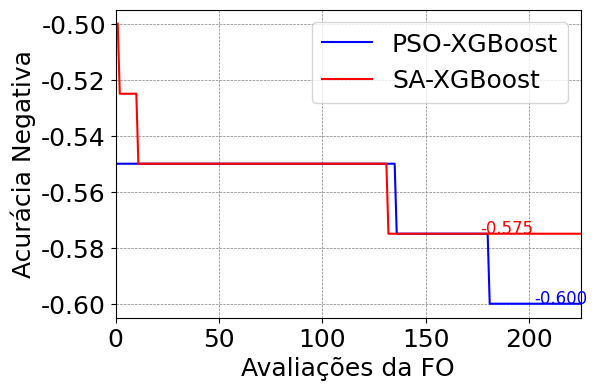

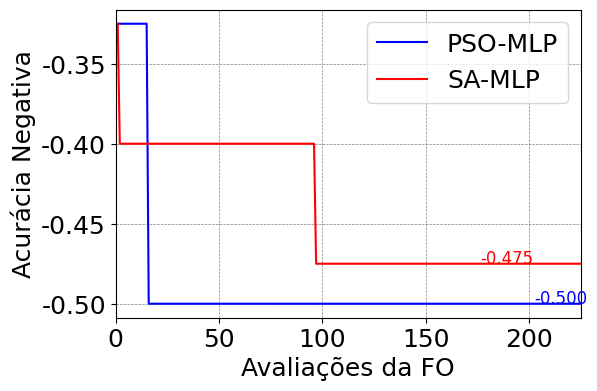

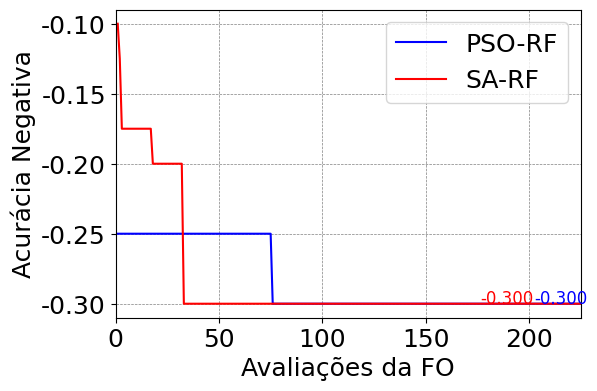

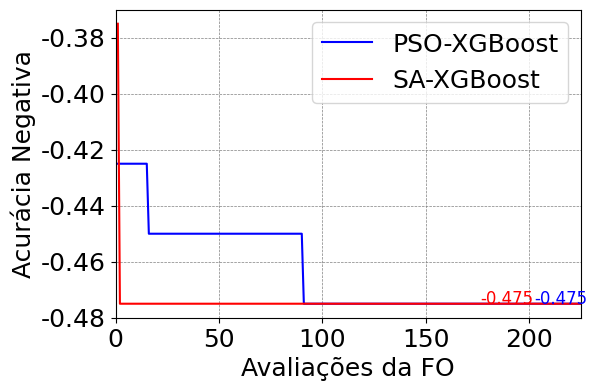

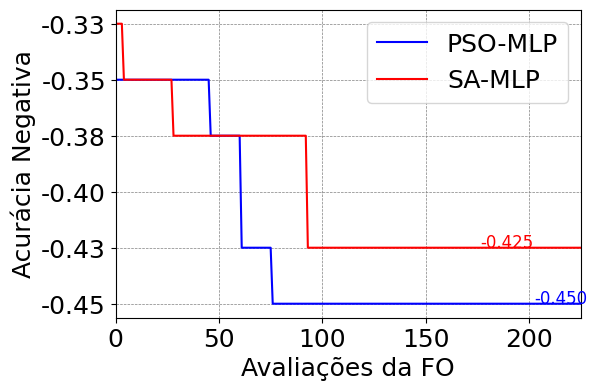

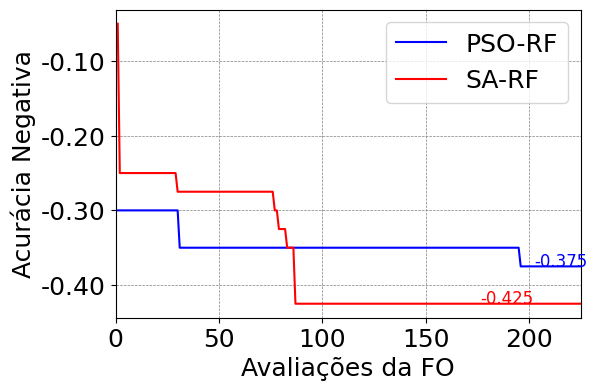

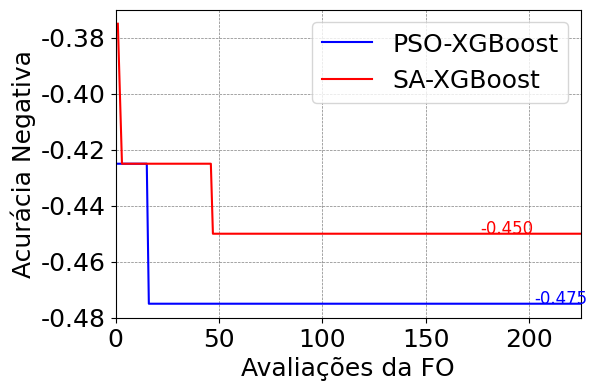

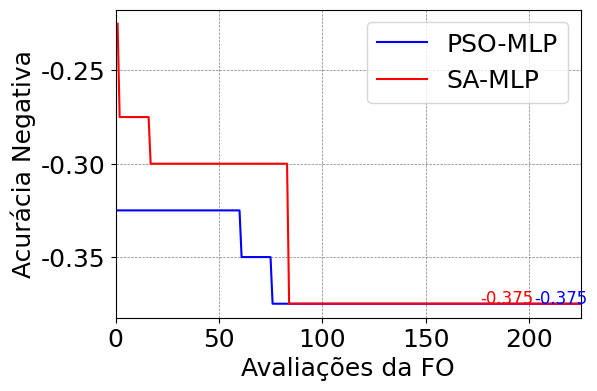

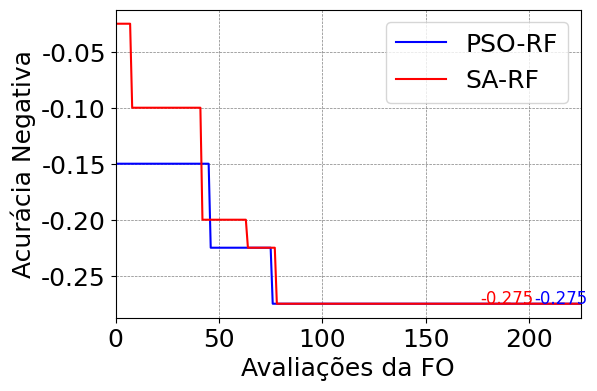

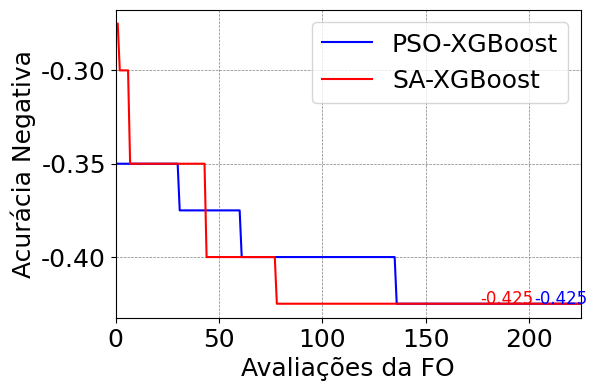

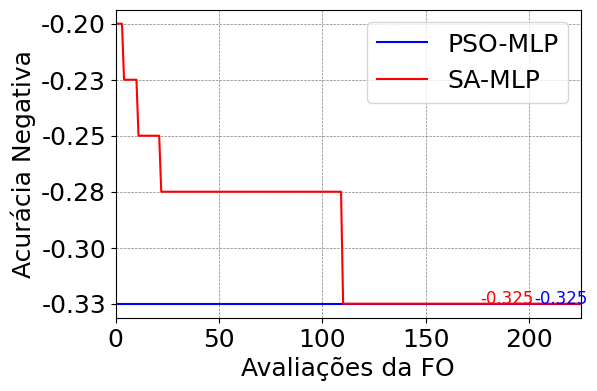

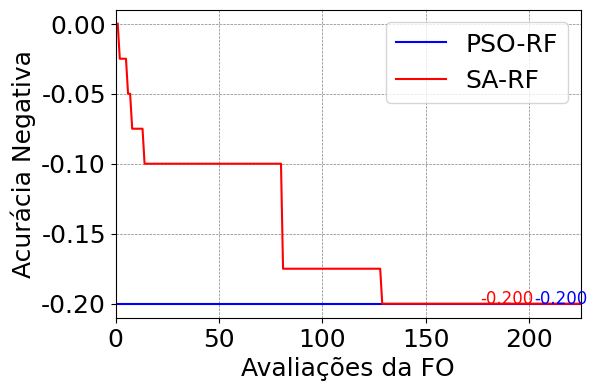

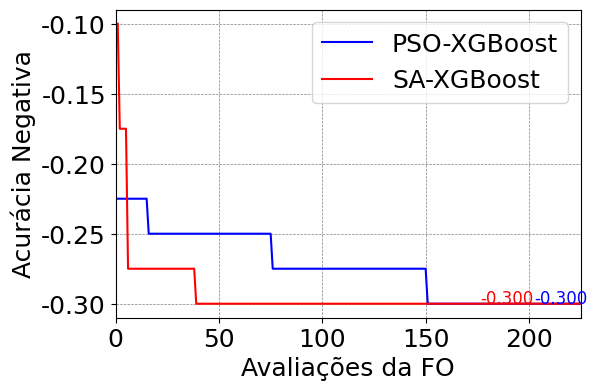

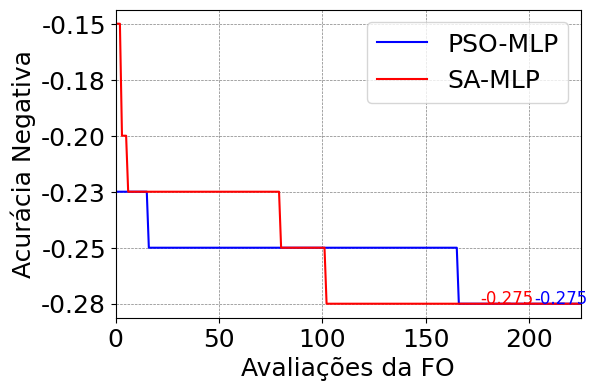

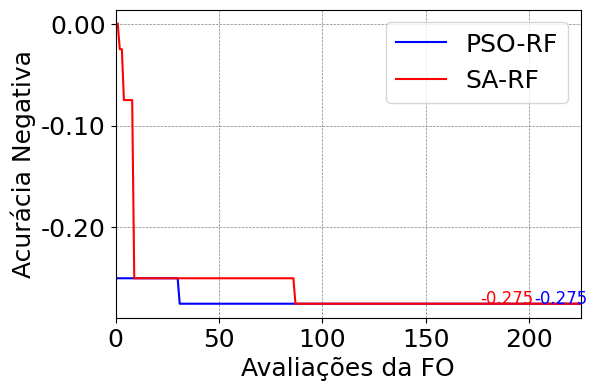

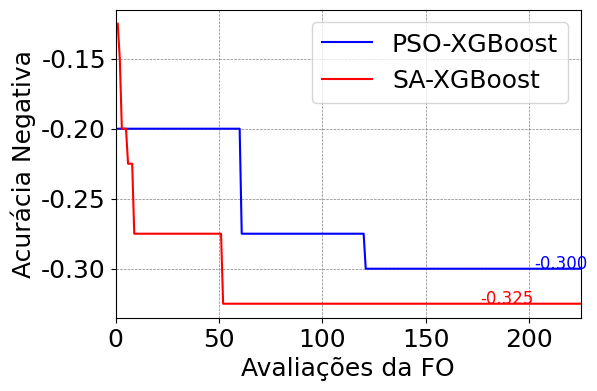

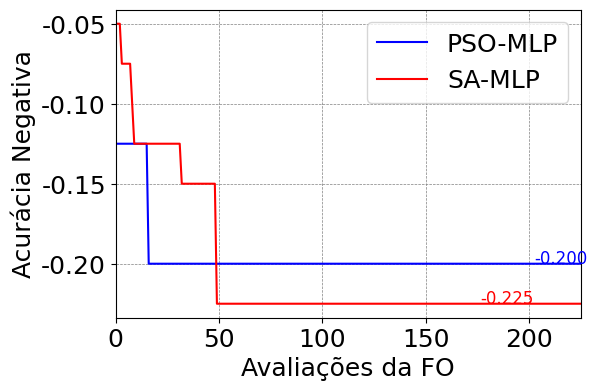

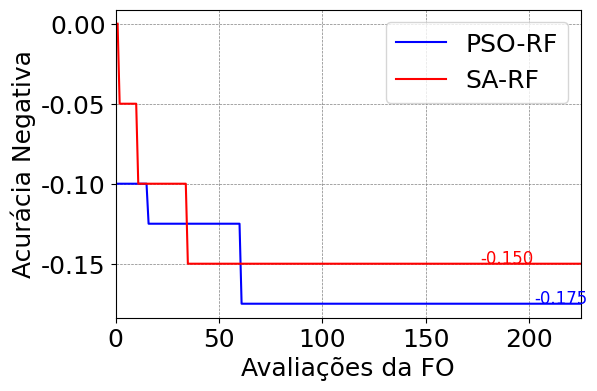

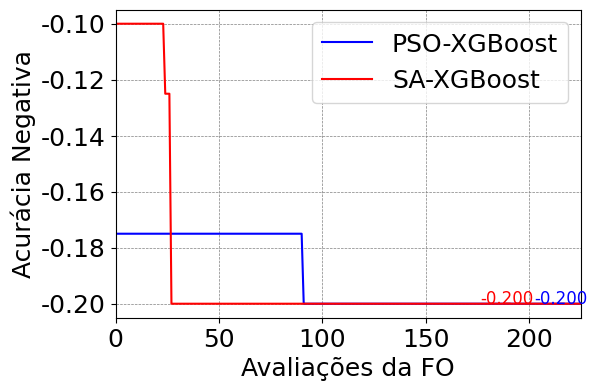

In [48]:
def formatar_y(valor, pos):
    if valor >= 1:
        return f"{valor:.2f}+"
    return f"{valor:.2f}"


for n_classe in N_CLASSES:
    for modelo in MODELOS:
        plt.figure(figsize=(6, 4))
        plt.rcParams['xtick.labelsize'] = 18
        plt.rcParams['ytick.labelsize'] = 18
        plt.rcParams.update({'font.size': 18})
        plt.rcParams['axes.prop_cycle'] = plt.cycler(
            color=["blue", "red"])

        for otimizador in OTIMIZADORES:
            df = pd.DataFrame()
            final_fitness = {}
            for seed in SEEDS:
                try:
                    novo_df = pd.read_csv(f'resultados/otimização - classificação/{n_classe} classes/{n_classe} CLASSES {otimizador}-{modelo} SEED {seed}.csv',
                                          sep=";",
                                          decimal=".", header=0)
                except Exception as e:
                    continue

                if otimizador == "PSO":
                    df[seed] = pd.concat([novo_df["Fitness"].to_frame()] * N_ITER, ignore_index=True)
                    df[seed] = sorted(df[seed].values, reverse=True)
                else:
                    df[seed] = novo_df["Fitness"]
                final_fitness[seed] = novo_df["Fitness"].iloc[-1]  # Último valor de Fitness para cada seed

            df = np.round(df, decimals=10)
            best_seed = min(final_fitness, key=final_fitness.get)
            plt.plot(range(1, len(df) + 1), [x for x in df[best_seed]], label=f"{otimizador}-{modelo}")


            best_fitness = final_fitness[best_seed]
            color = plt.rcParams['axes.prop_cycle'].by_key()['color'][OTIMIZADORES.index(otimizador)]
            plt.annotate(f"{best_fitness:.3f}",
                         xy=(len(df) * (0.9 if otimizador == "PSO" else 0.78) , best_fitness),
                         fontsize=12,
                         color=color)

        plt.xlabel('Avaliações da FO')
        plt.ylabel('Acurácia Negativa')
        plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_y))
        plt.xlim(0, N_ITER * N_SOLUCOES)
        ax = plt.gca()
        ax.set_facecolor('white')
        plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
        plt.legend(facecolor='white')
        plt.savefig(f"./resultados/otimização - classificação/{n_classe} classes/{modelo}.png", bbox_inches='tight')
        plt.show()

In [46]:
best = {}
for n_classe in N_CLASSES:
    for modelo in MODELOS:
        df = []
        for otimizador in OTIMIZADORES:
            for seed in SEEDS:
                try:
                    novo_df = pd.read_csv(f'resultados/otimização - classificação/{n_classe} classes/{n_classe} CLASSES {otimizador}-{modelo} SEED {seed}.csv',
                                          sep=";",
                                          decimal=".", header=0)
                    df.append(novo_df.tail(1))
                except Exception as e:
                    continue
        df = pd.concat(df, ignore_index=True)
        df = df.sort_values(by=["Fitness"])
        df[df.isnull()] = None
        best[f"{n_classe}-{modelo}"] = df[:1]



In [15]:
for key, val in best.items():
    print(f"{key}")
    display(val)

2-MLP


,Unnamed: 0,Hidden Layers,Alpha,Activation,Fitness
3,14,18,0.626604,logistic,-0.95


2-RF


,Unnamed: 0,N_estimators,Max_depth,Min_samples_split,Min_samples_leaf,Fitness
13,225,16.0,258.0,9.0,2.0,-0.85


2-XGBoost


...

,Unnamed: 0,Hidden Layers,Alpha,Activation,Fitness
11,225,32,0.55,identity,-0.225


10-RF


,Unnamed: 0,N_estimators,Max_depth,Min_samples_split,Min_samples_leaf,Fitness
8,14,140.0,133.0,16.0,2.0,-0.175


10-XGBoost


,Unnamed: 0,N_estimators,Max_depth,Booster,Lambda,Alpha,Fitness
0,14,357,129,gbtree,0.9625,0.0446,-0.2
